# Fine-Tuning Experiments

Ноутбук фиксирует экспериментальный этап: описание датасета, сравнение моделей из разных семейств `timm`, подбор гиперпараметров, accuracy, confusion matrix и кривые обучения.

## Dataset

Датасет лежит в `../data/raw` и содержит три класса: `class1` (бабочки), `class2` (собаки), `class3` (змеи). Задача - классифицировать изображение животного в один из трех известных классов.

Предобработка: resize до 224x224, нормализация ImageNet. Для train используются `RandomHorizontalFlip`, `RandomRotation(15)` и `ColorJitter`.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == 'experiments' else Path.cwd()
RUNS_DIR = PROJECT_ROOT / 'experiments' / 'runs'
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'

class_counts = []
for class_dir in sorted(DATA_RAW.iterdir()):
    if class_dir.is_dir():
        count = sum(1 for path in class_dir.iterdir() if path.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif', '.tiff'})
        class_counts.append({'class': class_dir.name, 'images': count})

pd.DataFrame(class_counts)

,class,images
0,class1,70
1,class2,98
2,class3,116


## Training Commands

Запуски для сравнения двух семейств моделей:

```powershell
python .\experiments\train.py --run-name resnet18_lr001 --force-resplit --model-name resnet18 --epochs 5 --batch-size 16 --lr 0.001
python .\experiments\train.py --run-name efficientnet_b0_lr001 --model-name efficientnet_b0 --epochs 5 --batch-size 16 --lr 0.001
```

Дополнительный подбор learning rate:

```powershell
python .\experiments\train.py --run-name resnet18_lr0003 --model-name resnet18 --epochs 5 --batch-size 16 --lr 0.0003
python .\experiments\train.py --run-name efficientnet_b0_lr0003 --model-name efficientnet_b0 --epochs 5 --batch-size 16 --lr 0.0003
```

## Transfer Learning Strategy

В каждом запуске создается предобученная модель `timm` с новым classifier на 3 класса. Сначала backbone заморожен, поэтому обучается только classifier. После `freeze_backbone_epochs` backbone размораживается, и вся модель дообучается с уменьшенным learning rate. Такая стратегия снижает риск переобучения на небольшом датасете и позволяет адаптировать признаки под новые классы.

In [5]:
summaries = []
for summary_path in sorted(RUNS_DIR.glob('*/logs/summary.json')):
    with summary_path.open('r', encoding='utf-8') as file:
        summary = json.load(file)
    summaries.append({
        'run': summary_path.parents[1].name,
        'model': summary['model_name'],
        'epochs': summary['epochs'],
        'batch_size': summary['batch_size'],
        'lr': summary['lr'],
        'best_val_acc': summary['best_val_acc'],
        'class_weights': summary['use_class_weights'],
    })

results = pd.DataFrame(summaries).sort_values('best_val_acc', ascending=False)
results

,run,model,epochs,batch_size,lr,best_val_acc,class_weights
0,efficientnet_b0_lr0003,efficientnet_b0,5,16,0.0003,1.000000,True
1,efficientnet_b0_lr001,efficientnet_b0,5,16,0.0010,1.000000,True
3,resnet18_lr001,resnet18,5,16,0.0010,1.000000,True
2,resnet18_lr0003,resnet18,5,16,0.0003,0.982759,True


## Learning Curves

efficientnet_b0_lr0003


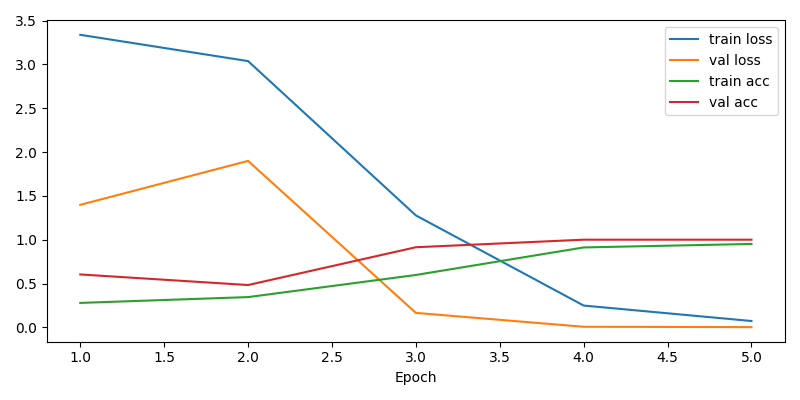

efficientnet_b0_lr001


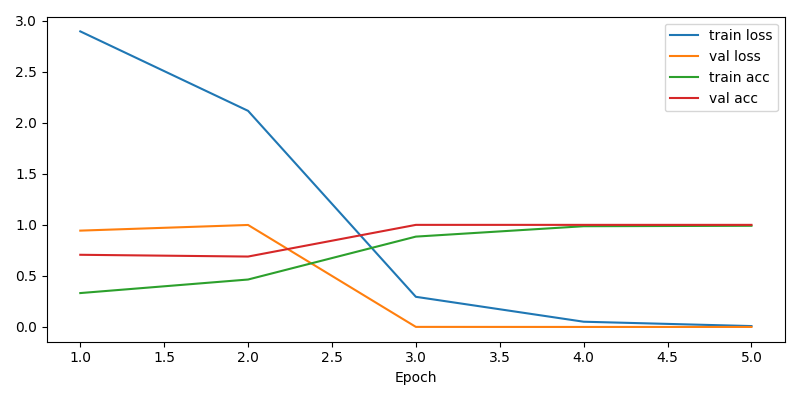

resnet18_lr0003


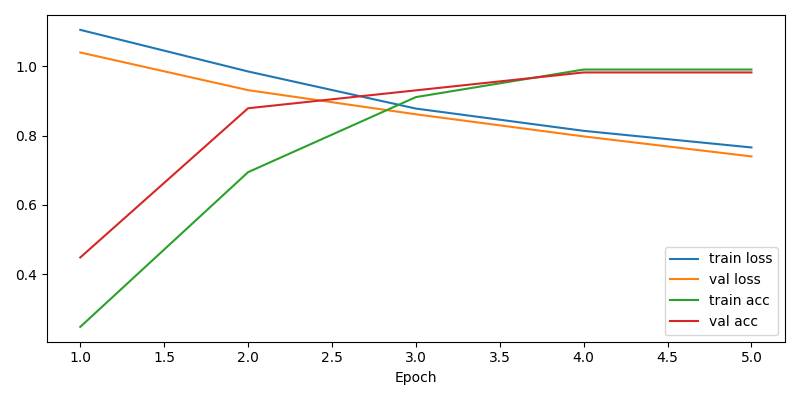

resnet18_lr001


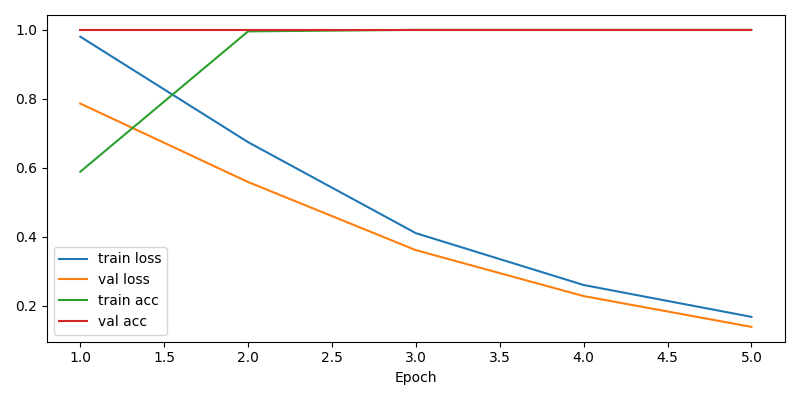

In [3]:
for curve_path in sorted(RUNS_DIR.glob('*/logs/learning_curves.png')):
    print(curve_path.parents[1].name)
    display(Image(filename=str(curve_path)))

## Confusion Matrices

efficientnet_b0_lr0003


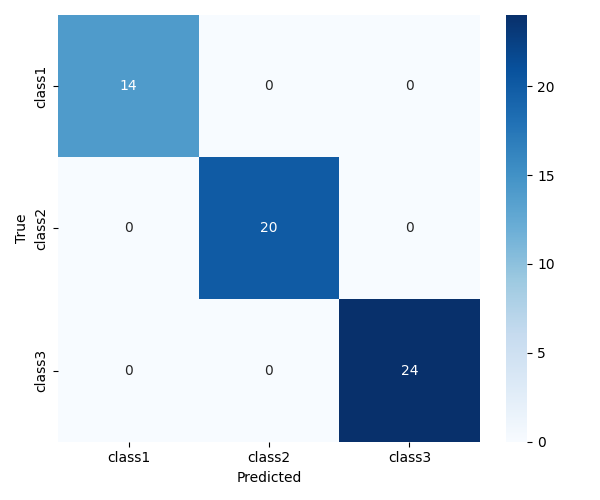

efficientnet_b0_lr001


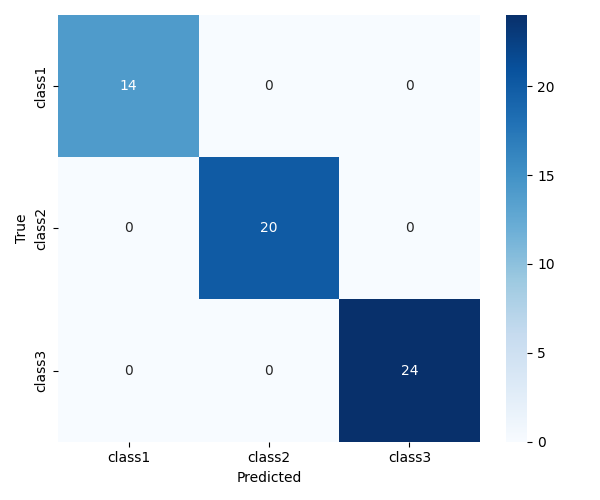

resnet18_lr0003


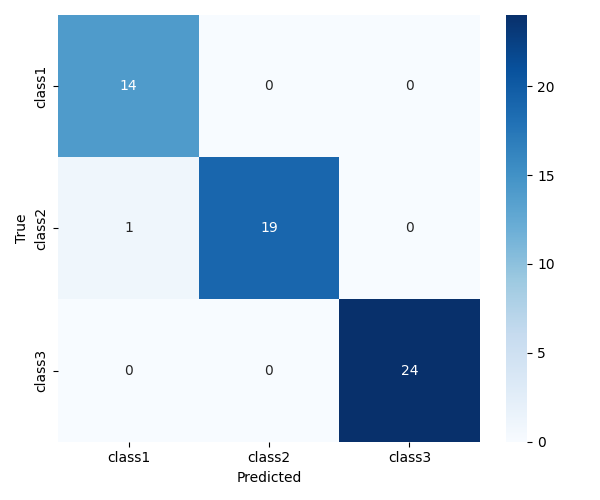

resnet18_lr001


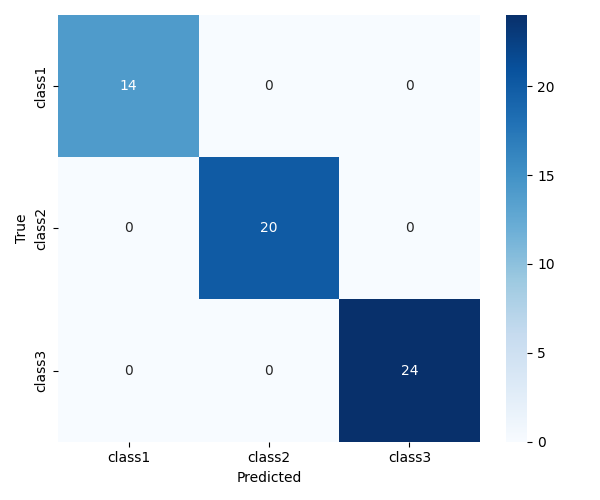

In [4]:
for matrix_path in sorted(RUNS_DIR.glob('*/logs/confusion_matrix.png')):
    print(matrix_path.parents[1].name)
    display(Image(filename=str(matrix_path)))

## Recorded Results

| Run | Family | Model | LR | Best val accuracy |
| --- | --- | --- | --- | --- |
| `resnet18_lr001` | ResNet | `resnet18` | 0.001 | 1.0000 |
| `resnet18_lr0003` | ResNet | `resnet18` | 0.0003 | 0.9828 |
| `efficientnet_b0_lr001` | EfficientNet | `efficientnet_b0` | 0.001 | 1.0000 |
| `efficientnet_b0_lr0003` | EfficientNet | `efficientnet_b0` | 0.0003 | 1.0000 |

Все модели обучались 5 эпох с batch size 16. Использовались предобученные веса, заморозка backbone на первых 2 эпохах, затем разморозка всей модели и уменьшенный learning rate для fine-tuning.

## Analysis Template

По результатам экспериментов максимальная validation accuracy достигнута в трех запусках: `resnet18_lr001`, `efficientnet_b0_lr001` и `efficientnet_b0_lr0003`. Запуск `resnet18_lr0003` показал немного более низкий результат (`0.9828`), значит learning rate `0.0003` для ResNet оказался менее удачным на 5 эпохах.

Для итогового ONNX-инференса выбран последний успешный запуск `efficientnet_b0_lr0003`: он относится к другому семейству, чем ResNet, достиг `best_val_acc = 1.0000` и был экспортирован в `experiments/models/best_model.onnx` для приложения.

Кривые обучения нужно использовать для проверки переобучения: если train accuracy растет быстрее validation accuracy или validation loss начинает расти, это признак переобучения. В текущих запусках validation accuracy быстро выходит на высокий уровень, что может означать либо хорошую разделимость классов, либо слишком простой/однородный validation split.

Матрицы ошибок нужно смотреть по каждому запуску в `experiments/runs/<run-name>/logs/confusion_matrix.png`. Если в матрице есть ошибки, они показывают, какие классы модель путает чаще всего. Если матрица диагональная, модель корректно классифицировала все объекты validation-набора.

Компромисс между семействами: ResNet18 проще и быстрее, EfficientNet-B0 обычно дает более эффективное качество на параметр, но может быть чувствительнее к гиперпараметрам. В данной задаче оба семейства показали высокий результат, поэтому выбор лучшей модели делается по validation accuracy, стабильности кривых и качеству матрицы ошибок.